# Data exploration for baseline model
In this notebook, we conduct an exploratory data analysis for the baseline model, whose variables include Hour, Day, Month, Public Holiday, School Holiday, Site, Direction (in and out), Hour × Day, and Hour × Direction. We also examine the important external continuous variable Fuel Price.

First, we check for missing values and find that there are no missing values among these variables. We then examine the counts for each variable and find that Hour, Day, Month, Site, and Direction are relatively balanced in their distributions. In contrast, Public Holiday and School Holiday show a more imbalanced pattern, with fewer cyclist counts during holiday periods. As for Fuel Price, its distribution lies within a moderate range, and fuel prices fluctuate over time.

Then, for the response variable (count_rescaled), the distribution is highly concentrated at low values and strongly right-skewed, with many zero values. Finally, we examine the correlations among the variables. The positive Spearman correlation indicates that cyclist traffic tends to be higher in later time intervals, but the relationship is not purely linear and should therefore be analysed through the full count model rather than through correlation alone.

### Import packages

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Load data

In [29]:
project_folder = Path("..")
processed_folder = project_folder / "data" / "processed"
eda_folder = processed_folder / "eda_model1"
eda_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Blues")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv(processed_folder / "counts_model_final.csv", parse_dates=["date", "installation_date"])

### Identify category variables and interaction terms

In [30]:
eda_df = df.copy()

# Standardize / rename variables for EDA
eda_df["hour_bin"] = eda_df["hour_bin"]
eda_df["weekday"] = pd.Categorical(
    eda_df["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
eda_df["month"] = pd.Categorical(
    eda_df["month"],
    categories=list(range(1, 13)),
    ordered=True
)
eda_df["is_public_holiday"]= pd.Categorical(
    eda_df["is_public_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["is_school_holiday"] = pd.Categorical(
    eda_df["is_school_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["site_id"] = eda_df["site_id"].astype(str)
eda_df["direction"] = pd.Categorical(
    eda_df["direction"]
)

# Interaction terms
eda_df["hour_day"] = eda_df["hour_bin"].astype(str) + "_" + eda_df["weekday"].astype(str)
eda_df["hour_direction"] = eda_df["hour_bin"].astype(str) + "_" + eda_df["direction"].astype(str)

### Missing value check for categorical variables and interaction terms

In [31]:
model_vars = [
    "hour_bin", "weekday", "month", "is_public_holiday", "is_school_holiday",
    "site_id", "direction", "hour_day", "hour_direction"
]

missing_summary = (
    eda_df[model_vars]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["missing_pct"] = missing_summary["missing_n"] / len(eda_df)

missing_summary.to_csv(eda_folder / "missing_summary_model1.csv", index=False)
missing_summary

,variable,missing_n,missing_pct
0,hour_bin,0,0.0
1,weekday,0,0.0
2,month,0,0.0
3,is_public_holiday,0,0.0
4,is_school_holiday,0,0.0
5,site_id,0,0.0
6,direction,0,0.0
7,hour_day,0,0.0
8,hour_direction,0,0.0


### Counts summary table and plots for categorical variables

In [33]:

# summary table

def make_count_summary(data, var_name):
    s = data[var_name]
    tab = s.value_counts(dropna=False)
    total_n = len(s)
    nonmissing_n = s.notna().sum()
    missing_n = s.isna().sum()
    n_levels = s.nunique(dropna=True)
    max_share = (tab.iloc[0] / total_n) if len(tab) > 0 else np.nan
    min_share = (tab.iloc[-1] / total_n) if len(tab) > 0 else np.nan

    return pd.DataFrame({
        "variable": [var_name],
        "total_n": [total_n],
        "nonmissing_n": [nonmissing_n],
        "missing_n": [missing_n],
        "missing_share": [missing_n / total_n],
        "n_levels": [n_levels],
        "largest_level_n": [tab.iloc[0] if len(tab) > 0 else np.nan],
        "largest_level_share": [max_share],
        "smallest_level_n": [tab.iloc[-1] if len(tab) > 0 else np.nan],
        "smallest_level_share": [min_share]
    })

summary_vars = [
    "hour_bin", "weekday", "month", "is_public_holiday",
    "is_school_holiday", "direction", "site_id",
    "hour_day", "hour_direction"
]

counts_summary_compact = pd.concat(
    [make_count_summary(eda_df, v) for v in summary_vars],
    ignore_index=True
)

counts_summary_compact.to_csv(eda_folder / "counts_summary_compact.csv", index=False)
counts_summary_compact

,variable,total_n,nonmissing_n,missing_n,missing_share,n_levels,largest_level_n,largest_level_share,smallest_level_n,smallest_level_share
0,hour_bin,4587736,4587736,0,0.0,12,382495,0.083373,381172,0.083085
1,weekday,4587736,4587736,0,0.0,7,657070,0.143223,654079,0.142571
2,month,4587736,4587736,0,0.0,12,408688,0.089083,340124,0.074138
3,is_public_holiday,4587736,4587736,0,0.0,2,4414804,0.962306,172932,0.037694
4,is_school_holiday,4587736,4587736,0,0.0,2,3281386,0.715252,1306350,0.284748
5,direction,4587736,4587736,0,0.0,2,2293874,0.500001,2293862,0.499999
6,site_id,4587736,4587736,0,0.0,149,35056,0.007641,854,0.000186
7,hour_day,4587736,4587736,0,0.0,84,54770,0.011938,53496,0.011661
8,hour_direction,4587736,4587736,0,0.0,24,191248,0.041687,190586,0.041542


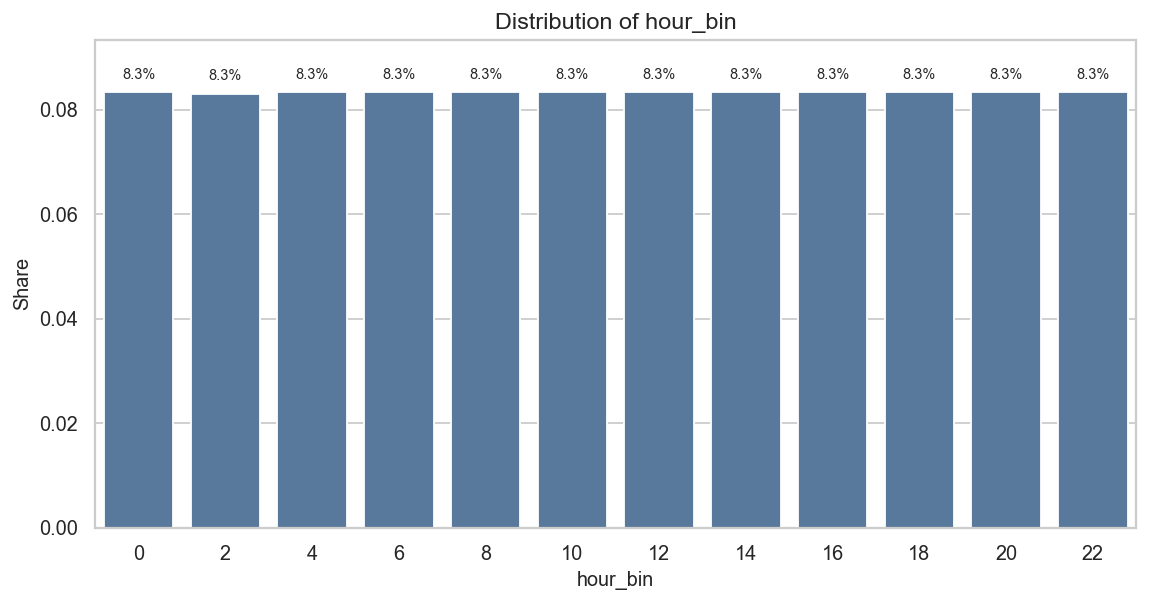

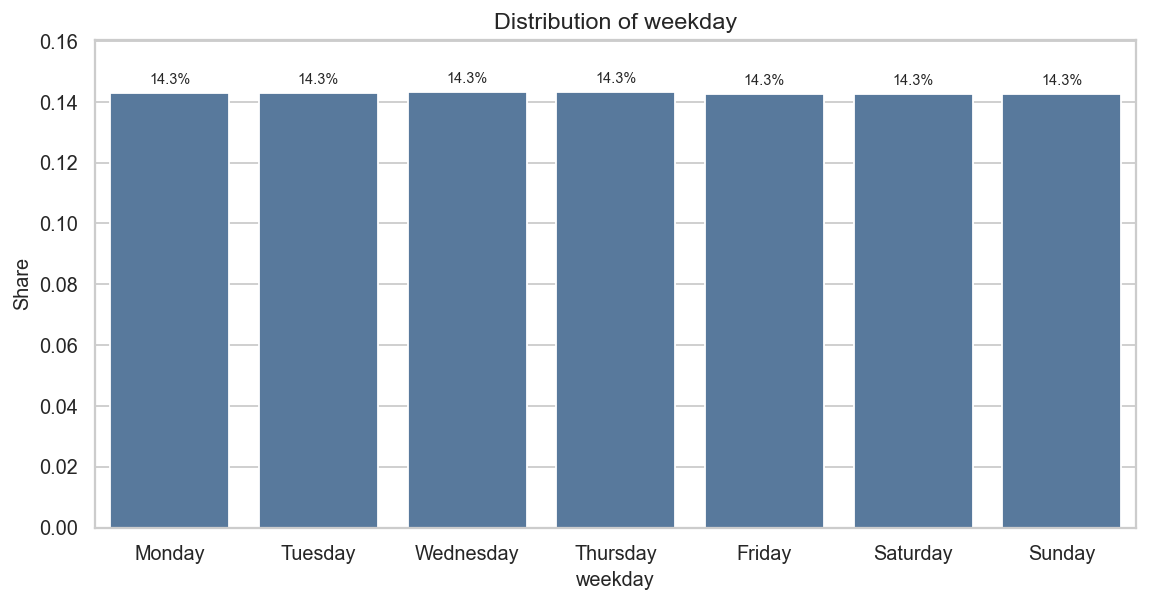

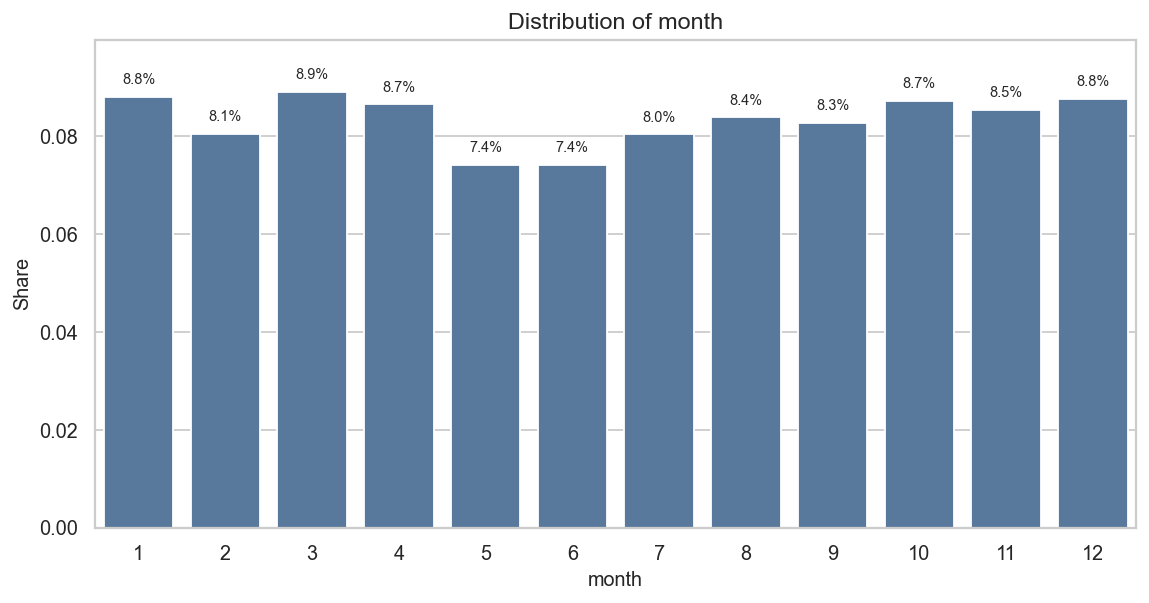

In [34]:
# Ordered bar charts: hour_bin / weekday / month

ordered_vars = {
    "hour_bin": list(sorted(eda_df["hour_bin"].dropna().unique())),
    "weekday": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    "month": list(range(1, 13))
}

for var_name, order in ordered_vars.items():
    plot_df = (
        eda_df[var_name]
        .value_counts(dropna=False)
        .reindex(order)
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(9, 4.8))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#4C78A8")
    ax.set_title(f"Distribution of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share")
    ax.set_ylim(0, plot_df["share"].max() * 1.12)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.002, f"{v:.1%}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_distribution_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

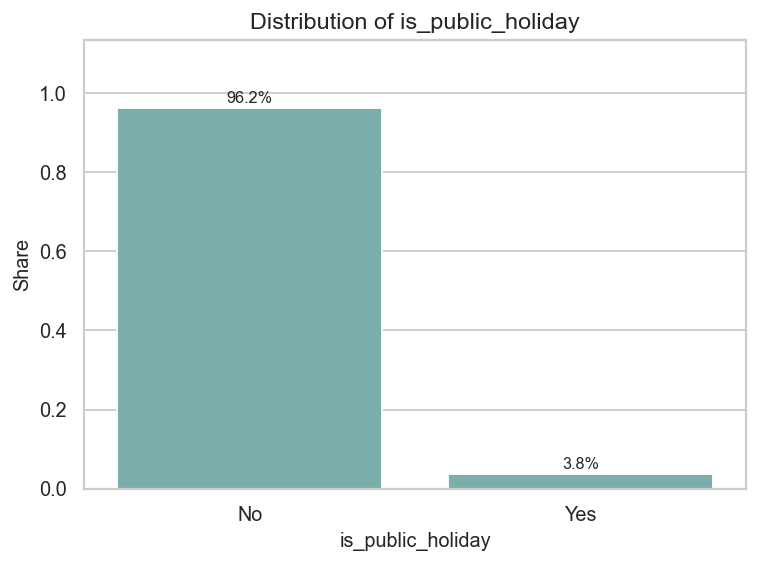

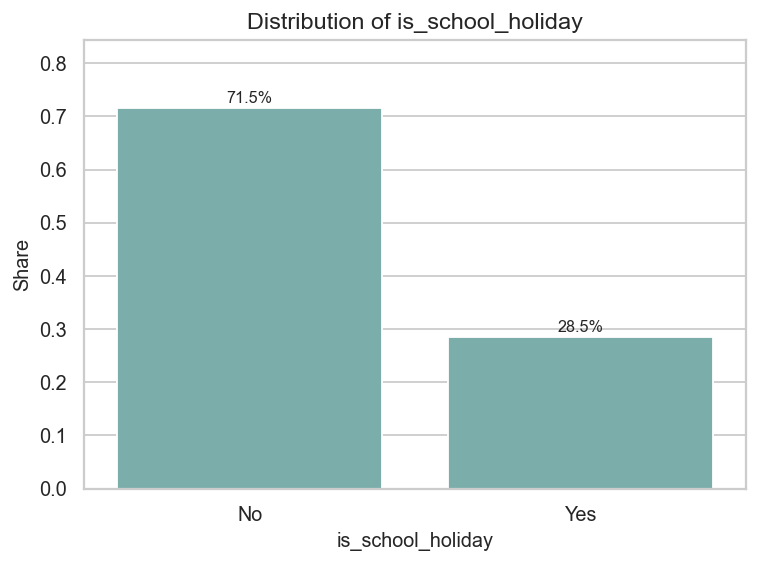

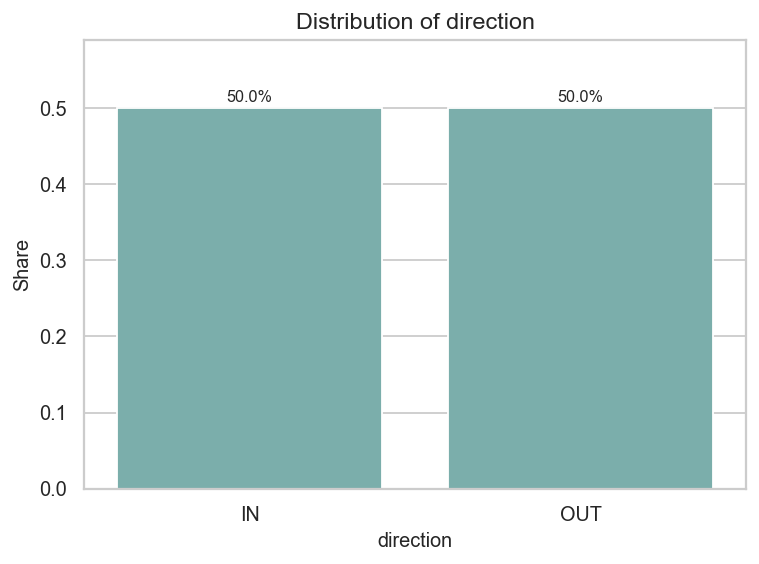

In [35]:
# Binary bar charts: Public_holiday / School_holiday / Direction

binary_vars = ["is_public_holiday", "is_school_holiday", "direction"]

for var_name in binary_vars:
    plot_df = (
        eda_df[var_name]
        .value_counts(dropna=False)
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(6, 4.5))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#72B7B2")
    ax.set_title(f"Distribution of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share")
    ax.set_ylim(0, plot_df["share"].max() * 1.18)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_distribution_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

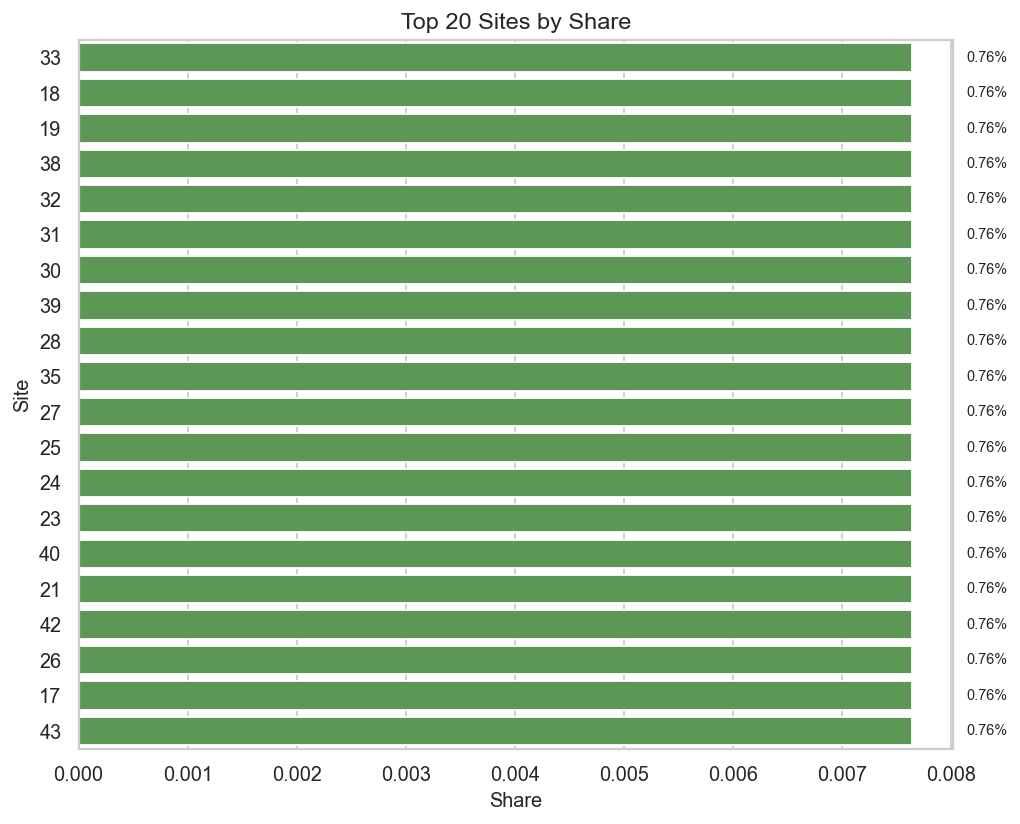

In [36]:
# Top-20 bar chart for site_id

top_n = 20

site_plot_df = (
    eda_df["site_id"]
    .value_counts(dropna=False)
    .head(top_n)
    .sort_values(ascending=True)
    .rename_axis("level")
    .reset_index(name="n")
)

site_plot_df["share"] = site_plot_df["n"] / len(eda_df)

plt.figure(figsize=(8, 6.5))
ax = sns.barplot(data=site_plot_df, x="share", y="level", color="#54A24B")
ax.set_title(f"Top {top_n} Sites by Share")
ax.set_xlabel("Share")
ax.set_ylabel("Site")

for i, v in enumerate(site_plot_df["share"]):
    ax.text(v + 0.0005, i, f"{v:.2%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(eda_folder / "site_top20_bar.png", bbox_inches="tight")
plt.show()
plt.close()

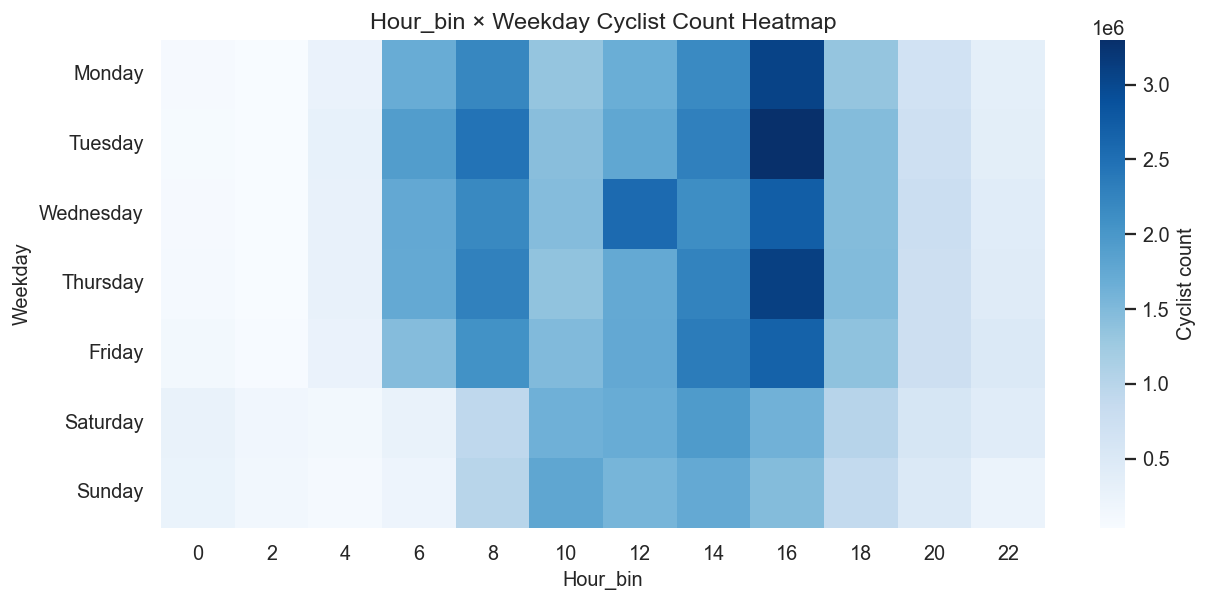

In [55]:
# Heatmap for Hour_bin × Weekday using cyclist counts

hour_day_heatmap = (
    eda_df
    .groupby(["weekday", "hour_bin"], observed=False)["count"]
    .sum()
    .unstack(fill_value=0)
)

hour_day_heatmap = hour_day_heatmap.reindex(
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

hour_day_heatmap = hour_day_heatmap.reindex(
    columns=sorted(hour_day_heatmap.columns)
)

plt.figure(figsize=(10, 4.8))
sns.heatmap(hour_day_heatmap, cmap="Blues", cbar_kws={"label": "Cyclist count"})
plt.title("Hour_bin × Weekday Cyclist Count Heatmap")
plt.xlabel("Hour_bin")
plt.ylabel("Weekday")
plt.tight_layout()
plt.savefig(eda_folder / "hour_day_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

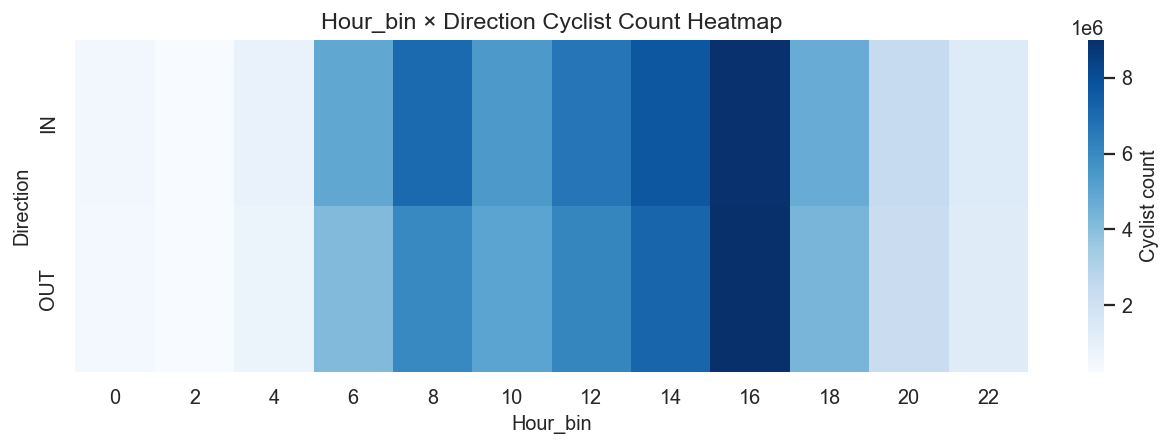

In [54]:
# Heatmap for Hour_bin × Direction using cyclist counts (sum)

hour_direction_heatmap = (
    eda_df
    .groupby(["direction", "hour_bin"], observed=False)["count"]
    .sum()
    .unstack(fill_value=0)
)

hour_direction_heatmap = hour_direction_heatmap.reindex(
    columns=sorted(hour_direction_heatmap.columns)
)

plt.figure(figsize=(10, 3.6))
sns.heatmap(hour_direction_heatmap, cmap="Blues", cbar_kws={"label": "Cyclist count"})
plt.title("Hour_bin × Direction Cyclist Count Heatmap")
plt.xlabel("Hour_bin")
plt.ylabel("Direction")
plt.tight_layout()
plt.savefig(eda_folder / "hour_direction_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

### Data exploration for Fuel prices

In [39]:
fuel_df = df.copy()

fuel_df["fuel_price_petrol_95_rounded"] = fuel_df["fuel_price_petrol_95"].round(2)

# Basic count 

fuel_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "unique_values_row_level"
    ],
    "value": [
        len(fuel_df),
        fuel_df["fuel_price_petrol_95_rounded"].notna().sum(),
        fuel_df["fuel_price_petrol_95_rounded"].isna().sum(),
        fuel_df["fuel_price_petrol_95_rounded"].isna().mean(),
        fuel_df["fuel_price_petrol_95_rounded"].nunique()
    ]
})

fuel_count_summary.to_csv(eda_folder / "fuelprice_count_summary.csv", index=False)
fuel_count_summary

,metric,value
0,total_rows,4587736.0
1,non_missing_rows,4587736.0
2,missing_rows,0.0
3,missing_share,0.0
4,unique_values_row_level,55.0


In [40]:
# Daily-level fuel price data
fuel_daily = (
    fuel_df[["date", "fuel_price_petrol_95_rounded"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

fuel_daily_summary = pd.DataFrame({
    "metric": [
        "unique_days",
        "non_missing_days",
        "missing_days",
        "unique_values_daily_level"
    ],
    "value": [
        len(fuel_daily),
        fuel_daily["fuel_price_petrol_95_rounded"].notna().sum(),
        fuel_daily["fuel_price_petrol_95_rounded"].isna().sum(),
        fuel_daily["fuel_price_petrol_95_rounded"].nunique()
    ]
})

fuel_daily_summary.to_csv(eda_folder / "fuelprice_daily_summary.csv", index=False)
fuel_daily_summary

,metric,value
0,unique_days,1461
1,non_missing_days,1461
2,missing_days,0
3,unique_values_daily_level,55


In [41]:
# Binned counts table

n_bins = 20

fuel_daily_nonmissing = fuel_daily.dropna(subset=["fuel_price_petrol_95_rounded"]).copy()

fuel_daily_nonmissing["fuelprice_bin"] = pd.cut(
    fuel_daily_nonmissing["fuel_price_petrol_95_rounded"],
    bins=n_bins
)

fuel_bin_counts = (
    fuel_daily_nonmissing["fuelprice_bin"]
    .value_counts(sort=False)
    .rename_axis("FuelPrice_bin")
    .reset_index(name="n")
)

fuel_bin_counts["share"] = fuel_bin_counts["n"] / fuel_bin_counts["n"].sum()

fuel_bin_counts.to_csv(eda_folder / "fuelprice_binned_counts.csv", index=False)
fuel_bin_counts

,FuelPrice_bin,n,share
0,"(1.449, 1.483]",42,0.028747
1,"(1.483, 1.516]",35,0.023956
2,"(1.516, 1.549]",147,0.100616
3,"(1.549, 1.582]",238,0.162902
4,"(1.582, 1.615]",133,0.091034
5,"(1.615, 1.648]",98,0.067077
6,"(1.648, 1.681]",119,0.081451
7,"(1.681, 1.714]",238,0.162902
8,"(1.714, 1.747]",70,0.047912
9,"(1.747, 1.78]",77,0.052704


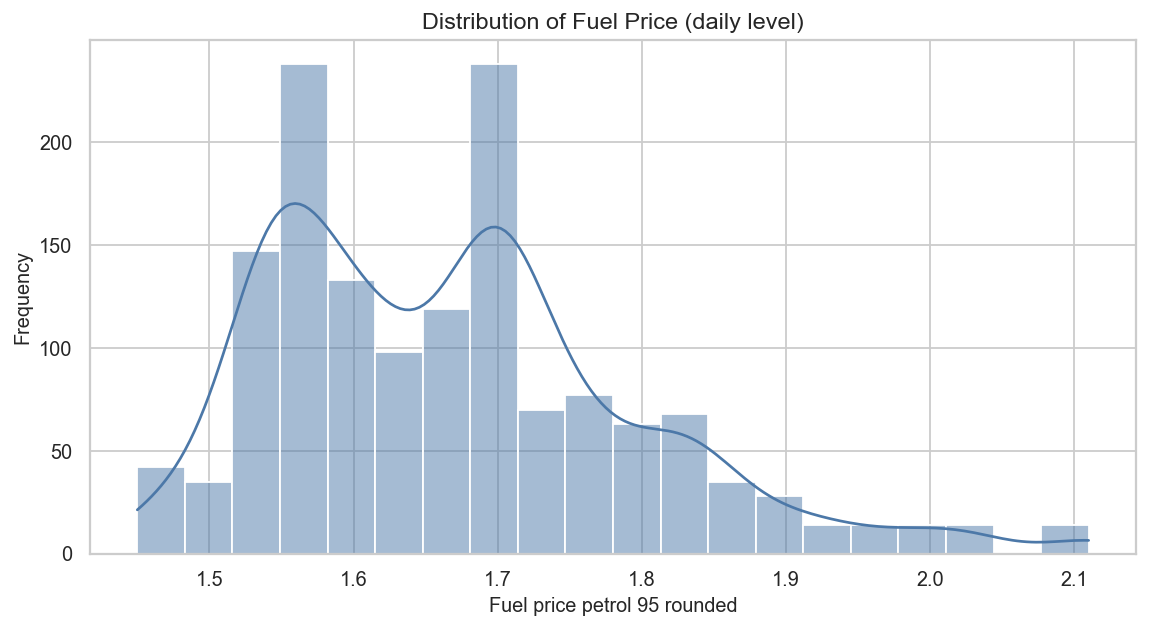

In [42]:
# Histogram + KDE (daily-level)

plt.figure(figsize=(9, 5))
sns.histplot(
    fuel_daily_nonmissing["fuel_price_petrol_95_rounded"],
    bins=20,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95 rounded")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_hist.png", bbox_inches="tight")
plt.show()
plt.close()

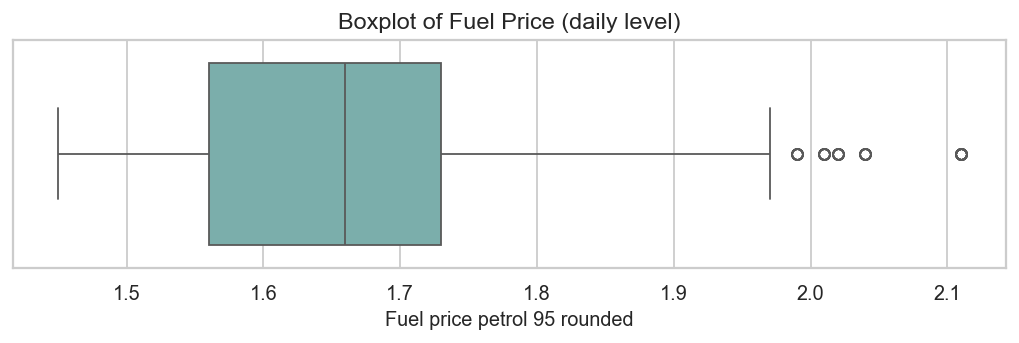

In [43]:
# Box plot (daily-level)

plt.figure(figsize=(8, 2.8))
sns.boxplot(
    x=fuel_daily_nonmissing["fuel_price_petrol_95_rounded"],
    color="#72B7B2",
    showfliers=True
)
plt.title("Boxplot of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95 rounded")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_boxplot.png", bbox_inches="tight")
plt.show()
plt.close()

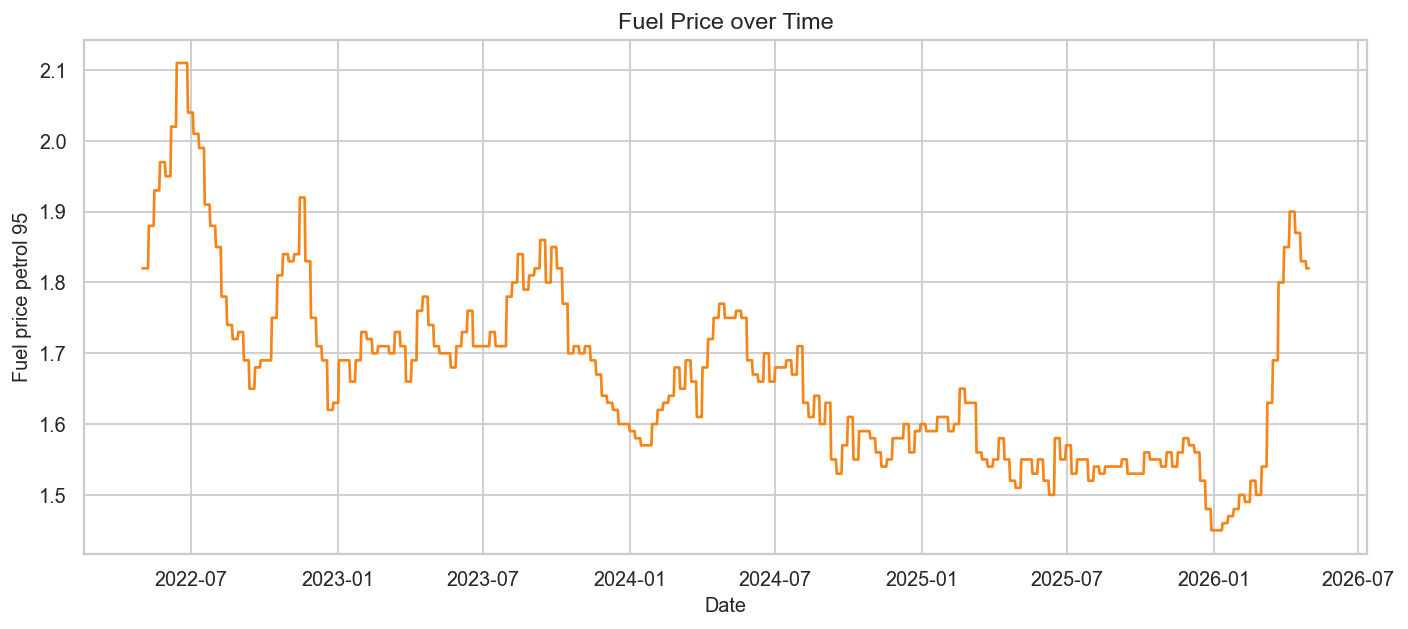

In [44]:
# Time-series plot

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=fuel_daily_nonmissing,
    x="date",
    y="fuel_price_petrol_95_rounded",
    color="#F58518"
)
plt.title("Fuel Price over Time")
plt.xlabel("Date")
plt.ylabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_time_series.png", bbox_inches="tight")
plt.show()
plt.close()

In [45]:
# Descriptive statistics

fuel_desc = (
    fuel_daily_nonmissing["fuel_price_petrol_95_rounded"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
fuel_desc.columns = ["statistic", "value"]

fuel_desc.to_csv(eda_folder / "fuelprice_descriptive_stats.csv", index=False)
fuel_desc

,statistic,value
0,count,1461.000000
1,mean,1.668884
2,std,0.127748
3,min,1.450000
4,1%,1.460000
5,5%,1.510000
6,25%,1.560000
7,50%,1.660000
8,75%,1.730000
9,95%,1.910000


### Data exploration for response variable (count_rescaled)

In [46]:
response_var = "count_rescaled"
response_df=df.copy()
response_df["count_rescaled"] = response_df[response_var]

# Basic count

response_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "zero_rows",
        "zero_share",
        "unique_values"
    ],
    "value": [
        len(response_df),
        response_df["count_rescaled"].notna().sum(),
        response_df["count_rescaled"].isna().sum(),
        response_df["count_rescaled"].isna().mean(),
        (response_df["count_rescaled"] == 0).sum(),
        (response_df["count_rescaled"] == 0).mean(),
        response_df["count_rescaled"].nunique()
    ]
})

response_count_summary.to_csv(eda_folder / "response_count_summary.csv", index=False)
response_count_summary

,metric,value
0,total_rows,4.587736e+06
1,non_missing_rows,4.587736e+06
2,missing_rows,0.000000e+00
3,missing_share,0.000000e+00
4,zero_rows,1.254674e+06
5,zero_share,2.734844e-01
6,unique_values,1.102000e+03


There is missing value in count_rescaled, but many 0 values.

In [47]:
# Binned counts table

n_bins = 30

response_nonmissing = response_df.dropna(subset=["count_rescaled"]).copy()

response_nonmissing["count_rescaled_bin"] = pd.cut(
    response_nonmissing["count_rescaled"],
    bins=n_bins
)

response_bin_counts = (
    response_nonmissing["count_rescaled_bin"]
    .value_counts(sort=False)
    .rename_axis("count_rescaled_bin")
    .reset_index(name="n")
)

response_bin_counts["share"] = response_bin_counts["n"] / response_bin_counts["n"].sum()

response_bin_counts.to_csv(eda_folder / "response_binned_counts.csv", index=False)
response_bin_counts

,count_rescaled_bin,n,share
0,"(-8.682, 289.4]",4560355,9.940317e-01
1,"(289.4, 578.8]",24548,5.350787e-03
2,"(578.8, 868.2]",2498,5.444951e-04
3,"(868.2, 1157.6]",236,5.144150e-05
4,"(1157.6, 1447.0]",40,8.718898e-06
5,"(1447.0, 1736.4]",33,7.193090e-06
6,"(1736.4, 2025.8]",8,1.743780e-06
7,"(2025.8, 2315.2]",4,8.718898e-07
8,"(2315.2, 2604.6]",4,8.718898e-07
9,"(2604.6, 2894.0]",2,4.359449e-07


Most of the observations lower than 289.4, and larges values lead to right-skew.

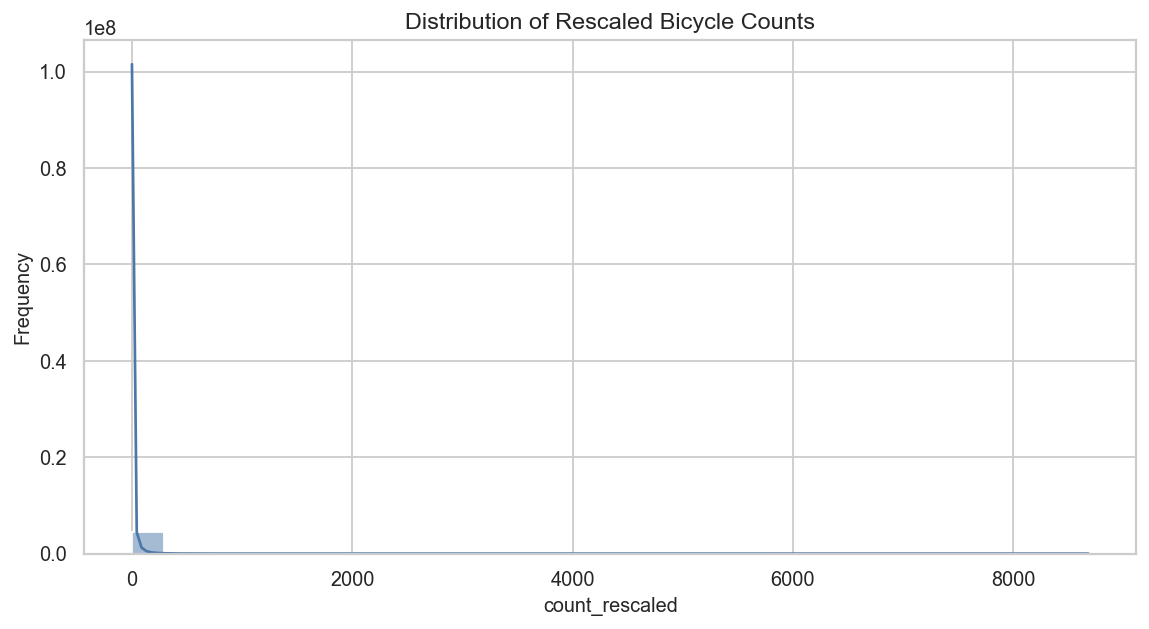

In [48]:
# Histogram + KDE

plt.figure(figsize=(9, 5))
sns.histplot(
    response_nonmissing["count_rescaled"],
    bins=30,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Rescaled Bicycle Counts")
plt.xlabel("count_rescaled")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist.png", bbox_inches="tight")
plt.show()
plt.close()

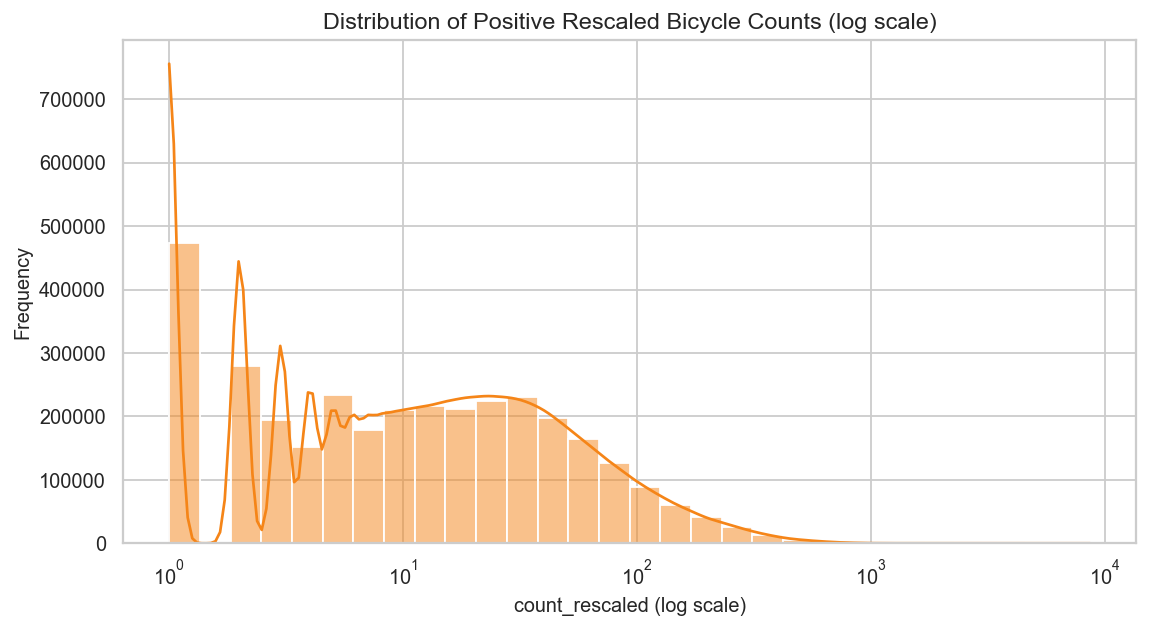

In [49]:
# log-scale histogram

response_positive = response_nonmissing[response_nonmissing["count_rescaled"] > 0].copy()

plt.figure(figsize=(9, 5))
sns.histplot(
    response_positive["count_rescaled"],
    bins=30,
    kde=True,
    color="#F58518",
    log_scale=True
)
plt.title("Distribution of Positive Rescaled Bicycle Counts (log scale)")
plt.xlabel("count_rescaled (log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist_logscale.png", bbox_inches="tight")
plt.show()
plt.close()

In [50]:
# Descriptive statistics

response_desc = (
    response_nonmissing["count_rescaled"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
response_desc.columns = ["statistic", "value"]

response_desc.to_csv(eda_folder / "response_descriptive_stats.csv", index=False)
response_desc

,statistic,value
0,count,4.587736e+06
1,mean,2.135951e+01
2,std,4.899166e+01
3,min,0.000000e+00
4,1%,0.000000e+00
5,5%,0.000000e+00
6,25%,0.000000e+00
7,50%,4.000000e+00
8,75%,2.100000e+01
9,95%,9.600000e+01


### Correlation analysis

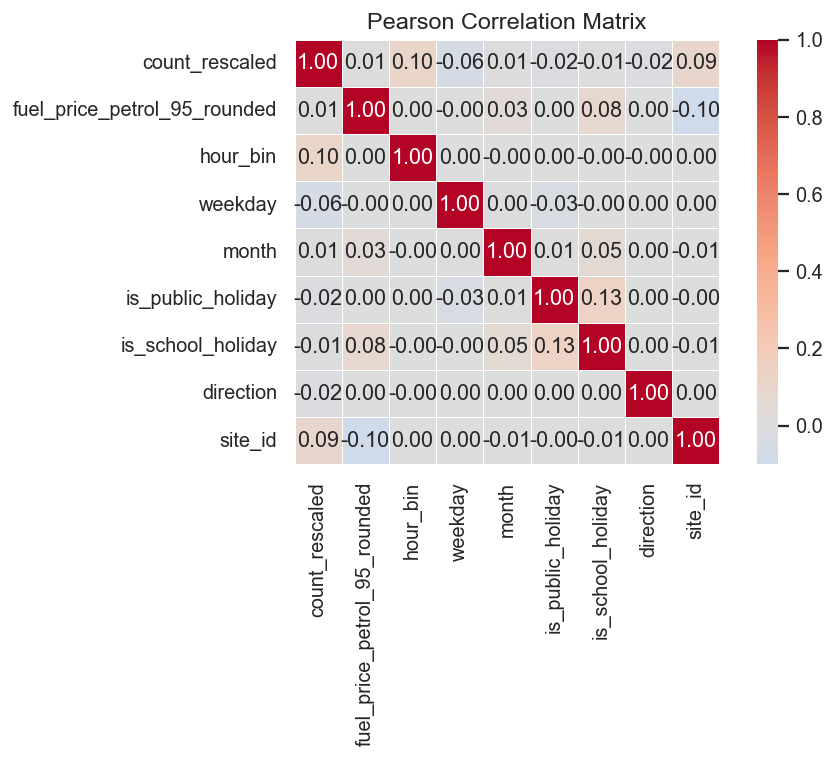

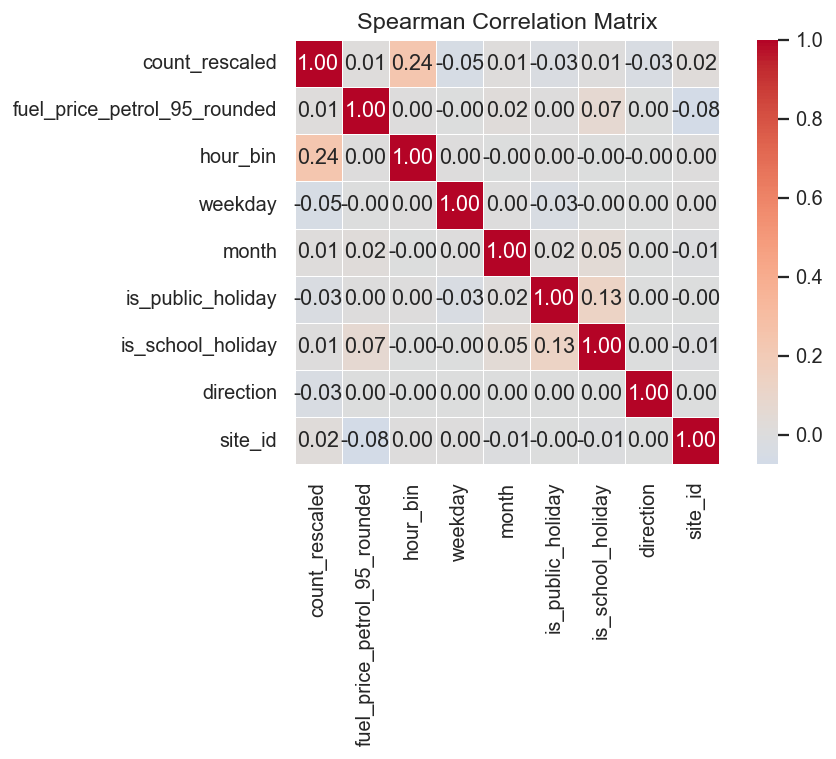

In [56]:
corrdf = df.copy()
corrdf["fuel_price_petrol_95_rounded"] = corrdf["fuel_price_petrol_95"].round(2)

corrdf["hour_bin"] = pd.to_numeric(corrdf["hour_bin"], errors="coerce")
corrdf["weekday"] = pd.Categorical(
    corrdf["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
).codes + 1
corrdf["month"] = pd.Categorical(
    corrdf["month"],
    categories=list(range(1, 13)),
    ordered=True
).codes + 1
corrdf["is_public_holiday"] = corrdf["is_public_holiday"].astype(float)
corrdf["is_school_holiday"] = corrdf["is_school_holiday"].astype(float)
corrdf["direction"] = corrdf["direction"].map({"IN": 0, "OUT": 1}).astype(float)
corrdf["site_id"] = pd.to_numeric(corrdf["site_id"], errors="coerce")

corr_vars = [
    "count_rescaled",
    "fuel_price_petrol_95_rounded",
    "hour_bin",
    "weekday",
    "month",
    "is_public_holiday",
    "is_school_holiday",
    "direction",
    "site_id"
]

corrdata = corrdf[corr_vars].dropna().copy()

pearson_corr = corrdata.corr(method="pearson")
spearman_corr = corrdata.corr(method="spearman")

pearson_corr.to_csv(eda_folder / "correlation_matrix_pearson.csv", index=True)
spearman_corr.to_csv(eda_folder / "correlation_matrix_spearman.csv", index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(eda_folder / "correlation_matrix_pearson.png", bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.savefig(eda_folder / "correlation_matrix_spearman.png", bbox_inches="tight")
plt.show()
plt.close()

outcome_corr = pd.DataFrame({
    "Pearson_with_Outcome": pearson_corr["count_rescaled"],
    "Spearman_with_Outcome": spearman_corr["count_rescaled"]
}).sort_values("Spearman_with_Outcome", key=lambda s: s.abs(), ascending=False)

outcome_corr.to_csv(eda_folder / "outcome_correlation_summary.csv", index=True)